In [1]:
import sys
sys.path.append('../..')

from src import utils
import src.channelCoding as cc
from pymongo import MongoClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl
import matplotlib.patheffects as pe
import hmac
import pickle


# MongoDB connection


clients = MongoClient('mongodb://localhost:27017/')
dbs = []
for db in clients.list_database_names():
    if db.startswith('r0_r1_SC_alpha'):
        dbs.append(clients[db]['destination, phase_1'])

db2 = clients['MAC_1D_R=0_5']
phase_trad_col = db2['destination, phase_1']

df_trad = pd.DataFrame(list(phase_trad_col.find({}, {'Decoded_tag_success':1, 'Decoded_msg_success':1, 'BER_msg': 1, 'BER_tag':1, 'SNR': 1})))
df_trad['SNR']= df_trad['SNR'].apply(lambda x: 10*np.log10(x))
# df_trad['BER_tag'] = df_trad['BER_tag'].apply(lambda x:binomial_tail(10, x))
df_trad.columns

/home/moh/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
2025-08-30 18:39:11.207811: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-30 18:39:11.217912: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756597151.230816 2637798 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for

Index(['_id', 'Decoded_tag_success', 'Decoded_msg_success', 'BER_msg',
       'BER_tag', 'SNR'],
      dtype='object')

In [2]:
# --- alpha from your docs ---------------------------------------------------
def infer_alpha(coll):
    return float(coll.find_one({})["config"]["ALPHA"])

def infer_msg_tag(coll):
    temp = coll.find_one({})["config"]
    len_MAC_encoded = int(np.ceil(256/temp["MAC_REP"]/temp["MAC_LDPC"]))
    len_msg = int(np.ceil((len_MAC_encoded - 512) * temp['MSG_CODE_RATE']))
    msg_str = temp['PAYLOAD'][:len_msg//8]
    msg_encoded = cc.encode_LDPC(utils.string_to_bits(msg_str), Codeword_length=len_MAC_encoded)
    tag = hmac.new(key=temp['MAC_KEY'].encode('utf-8'),
                   msg= msg_str.encode('utf-8'),
                     digestmod=temp['MAC_SHA']).hexdigest()
    tag_bits = utils.hex_to_bits(tag)
    tag_encoded = cc.encode_LDPC(tag_bits, Codeword_length=int(np.ceil(256/temp["MAC_LDPC"])))
    tag_encoded = np.repeat(tag_encoded, int(np.ceil(1//temp["MAC_REP"])))
    return msg_encoded, tag_encoded

In [3]:
# dfs = {}
# for db in dbs:
#     dfs[str(infer_alpha(db))] = pd.DataFrame(list(db.find({})))
# msg, tag = infer_msg_tag(dbs[0])


# dfs['strong_msg_ground_truth'] = list(map(int, msg))
# dfs['weak_msg_ground_truth'] = list(map(int, tag))

# # store the dfs in a pickle file
# import pickle
# with open("SC_df.pkl", "wb") as f:
#     pickle.dump(dfs, f)

# read the dfs from the pickle file
with open("SC_df.pkl", "rb") as f:
    dfs = pickle.load(f)

msg_bits = dfs['strong_msg_ground_truth']
tag_bits = dfs['weak_msg_ground_truth']

del dfs['strong_msg_ground_truth']
del dfs['weak_msg_ground_truth']

df_trad = dfs['0.0']
# del dfs['0.0']

df_trad['BER_tag'] = df_trad["BER_msg"]

df_trad.head()

,_id,BER_tag,BER_msg,r0,r1,SNR,sigma_n2,config
0,689f524433ecf1aab4931356,0.446066,0.446066,"[0.014967702416221723, 0.00010847762194900315,...","[0.019817596846566157, 4.518532282605204e-05, ...",0.576141,1.096457e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
1,689f524833ecf1aab4931358,0.435376,0.435376,"[6.591455987090919e-05, 9.034515179622474e-05,...","[0.00023894709943380368, 0.0001238336551998911...",0.487813,1.096437e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
2,689f525833ecf1aab493135c,0.441954,0.441954,"[0.0003911665962318455, 0.00012416727572418118...","[3.4292736580847825e-05, 0.0001175159371775629...",0.373613,1.114495e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
3,689f525c33ecf1aab493135e,0.438802,0.438802,"[0.016871033027971816, 0.00010438420217698962,...","[0.01337384623593236, 0.00035878864150685525, ...",0.530176,1.114423e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
4,689f526b33ecf1aab4931362,0.440927,0.440927,"[0.00011336254277659907, 8.266106669927841e-05...","[0.00024134050667587852, 1.1431705025852376e-0...",0.449184,1.117788e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."


BER_msg BER_tag


/tmp/ipykernel_2637798/3733131608.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(msg_cmap_name)


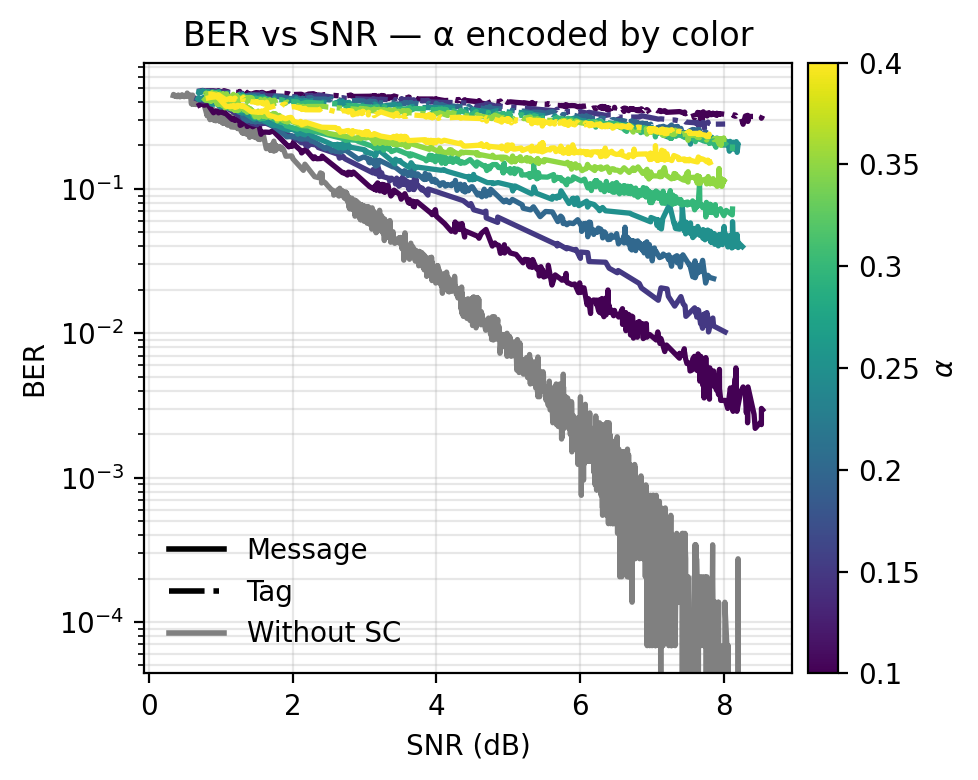

In [28]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

def df_from_dfs(dfs, col_name="BER_msg", col_name2="BER_tag"):
    print(col_name, col_name2)
    result = []
    for alpha_str, df in dfs.items():
        if not isinstance(df, pd.DataFrame):
            continue
        g = df.copy()
        for c in [col_name2, col_name, "SNR"]:
            g[c] = pd.to_numeric(g[c], errors="coerce")
        g = g.dropna(subset=[col_name2, col_name, "SNR"])
        g = (g.groupby("SNR", as_index=False)
               .agg(BER_tag=(col_name2,"mean"), BER_msg=(col_name,"mean"))
               .sort_values("SNR"))
        g["alpha"] = float(alpha_str)
        result.append((float(alpha_str), g))
    return result

def plot_ber_vs_snr_by_alpha_from_dfs(
    dfs, save_to=None, msg_cmap_name='viridis',  # single cmap for α
    col_name="BER_msg", col_name2="BER_tag"
):
    series = df_from_dfs(dfs, col_name=col_name, col_name2=col_name2)
    if not series:
        print("No data to plot.")
        return

    # sort by alpha
    series.sort(key=lambda x: x[0])
    alphas = [a for a, _ in series if a != 0]  # ignore baseline for color scaling
    if not alphas:
        alphas = [1.0]
    a_min, a_max = min(alphas), max(alphas)
    if a_max == a_min:
        a_max = a_min + 1e-12

    # color mapping for α
    cmap = mpl.cm.get_cmap(msg_cmap_name)
    norm = mpl.colors.Normalize(vmin=a_min, vmax=a_max)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    fig, ax = plt.subplots(figsize=(5, 4), dpi=200)

    for a, g in series:
        if a:  # curves with superposition use α color
            color = sm.to_rgba(a)
            ax.plot(g["SNR"], g['BER_msg'], linestyle="-",  linewidth=1.9, color=color, zorder=3)
            ax.plot(g["SNR"], g['BER_tag'], linestyle="-.", linewidth=1.9, color=color, zorder=3)
        else:  # baseline
            ax.plot(g["SNR"], g['BER_msg'], linestyle="-",  linewidth=1.9, color="grey", zorder=2, label="Without SC")

    ax.set_yscale("log")
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel("BER")
    ax.set_title("BER vs SNR — α encoded by color")
    ax.grid(True, which="both", alpha=0.3)

    # Colorbar showing α
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r"$\alpha$")
    # Make ticks land on your actual alpha values (sorted unique)
    unique_alphas = sorted(set([a for a, _ in series if a != 0]))
    if len(unique_alphas) <= 8:
        cbar.set_ticks(unique_alphas)
        cbar.set_ticklabels([f"{a:g}" for a in unique_alphas])

    # Minimal legend for line meaning (style, not color)
    ax.legend(handles=[
        Line2D([0],[0], color="black", lw=2, linestyle="-",  label="Message"),
        Line2D([0],[0], color="black", lw=2, linestyle="-.", label="Tag"),
        Line2D([0],[0], color="grey",  lw=2, linestyle="-",  label="Without SC"),
    ], loc="lower left", frameon=False)
    #plt.xlim([0,6])
    fig.tight_layout()
    if save_to:
        fig.savefig(save_to, dpi=220, bbox_inches="tight")
    plt.show()

# Usage:
plot_ber_vs_snr_by_alpha_from_dfs(dfs, save_to="ber_vs_snr_colorbar_alpha.png")


In [5]:
import numpy as np

def decode_superposed_fsk(
    E0, E1, snr, sigma_n2, alpha, snr_is_db=True, return_confidence=True
):
    """
    E0, E1: 1D arrays (or lists) of per-symbol energies in f0 and f1 bins
    snr: scalar SNR for these symbols (linear or dB)
    sigma_n2: scalar noise variance per bin
    alpha: fraction of total symbol power allocated to the WEAK layer (0..1)
    snr_is_db: if True, 'snr' is in dB and will be converted to linear
    return_confidence: if True, also return a per-symbol confidence score

    Returns:
      msg_bits: np.ndarray of 0/1 (strong layer: 0=>f0, 1=>f1)
      tag_bits: np.ndarray of 0/1 (weak  layer: 0=>f0, 1=>f1)
      confidences (optional): np.ndarray in [0,1], larger => more confident
    """
    E0 = np.asarray(E0, dtype=float)
    E1 = np.asarray(E1, dtype=float)
    assert E0.shape == E1.shape

    # SNR (linear) and power model
    snr_lin = 10**(snr/10.0) if snr_is_db else float(snr)
    P_tot   = snr_lin * sigma_n2              # total signal power per symbol
    P_str   = (1.0 - alpha) * P_tot           # strong layer power
    P_weak  = alpha * P_tot                   # weak  layer power
    N       = sigma_n2                        # mean noise energy in an empty bin

    # Expected mean energies for each hypothesis (E0_hat, E1_hat)
    # H00: strong f0 + weak f0  => f0: P_tot + N,     f1: N
    # H01: strong f0 + weak f1  => f0: P_str + N,     f1: P_weak + N
    # H10: strong f1 + weak f0  => f0: P_weak + N,    f1: P_str + N
    # H11: strong f1 + weak f1  => f0: N,             f1: P_tot + N
    means = np.array([
        [P_tot + N,     N        ],  # H00
        [P_str + N,     P_weak + N],  # H01
        [P_weak + N,    P_str + N],  # H10
        [N,             P_tot + N],  # H11
    ])  # shape (4, 2)

    # For speed, compute squared errors to each hypothesis, vectorized
    # errs[h, i] = (E0[i]-means[h,0])^2 + (E1[i]-means[h,1])^2
    E = np.stack([E0, E1], axis=0)            # (2, n)
    diffs = E[None, :, :] - means[:, :, None] # (4, 2, n)
    errs  = np.sum(diffs**2, axis=1)          # (4, n)

    # Best hypothesis per symbol
    idx = np.argmin(errs, axis=0)             # (n,)
    # Map hypothesis index -> (msg_bit, tag_bit)
    # H00 -> (0,0), H01 -> (0,1), H10 -> (1,0), H11 -> (1,1)
    map_bits = np.array([[0,0],[0,1],[1,0],[1,1]])
    decoded = map_bits[idx]
    msg_bits = decoded[:,0]
    tag_bits = decoded[:,1]

    if not return_confidence:
        return msg_bits, tag_bits

    # Simple confidence: margin between best and second-best hypothesis
    sorted_errs = np.sort(errs, axis=0)       # (4, n)
    margin = sorted_errs[1] - sorted_errs[0]  # (n,)
    # Normalize margin to [0,1] for convenience (robust min-max)
    if margin.size > 0:
        lo, hi = np.percentile(margin, [10, 90])
        denom = max(hi - lo, 1e-12)
        conf = np.clip((margin - lo) / denom, 0.0, 1.0)
    else:
        conf = margin
    return msg_bits, tag_bits, conf


# ---- Example usage with one row from your DataFrame ----
# Suppose a row has: r0 (list of energies in f0), r1 (list in f1),
# SNR (likely dB), sigma_n2, and you know alpha.
row = dfs['0.15'].iloc[170]
msg, tag, conf = decode_superposed_fsk(row['r0'], row['r1'],
                                       snr=row['SNR'], sigma_n2=row['sigma_n2'],
                                       alpha=0.15, snr_is_db=True)
row['SNR'], row['BER_msg'],np.sum(msg!=msg_bits)/len(msg_bits), row['BER_tag'],np.sum(tag!=tag_bits)/len(msg_bits)




(7.703593123864828,
 0.010827850877192983,
 0.010827850877192983,
 0.28803453947368424,
 0.4887609649122807)

In [6]:
import numpy as np

# ---- utilities ---------------------------------------------------------------
def _to_linear_snr(snr, snr_is_db):
    return 10**(snr/10.0) if snr_is_db else float(snr)

def _gauss_ll(x, P, sigma2):
    """
    Log-likelihood for energy x given signal power P and noise variance sigma2,
    using a Gaussian approx to the noncentral-chi^2 energy.
      mean = P + sigma2
      var  = sigma2**2 + 2*P*sigma2
    Returns log p(x | P, sigma2) up to an additive constant independent of P.
    """
    mu = P + sigma2
    var = sigma2**2 + 2.0*P*sigma2
    var = np.maximum(var, 1e-18)
    return -0.5*((x - mu)**2/var + np.log(var))

def _logsumexp(a, axis=0):
    m = np.max(a, axis=axis, keepdims=True)
    return (m + np.log(np.sum(np.exp(a - m), axis=axis, keepdims=True))).squeeze(axis)

# ---- expected powers for the four hypotheses --------------------------------
# H00: strong→f0, weak→f0
# H01: strong→f0, weak→f1
# H10: strong→f1, weak→f0
# H11: strong→f1, weak→f1
def _hypothesis_powers(P_str, P_weak):
    return np.array([
        [P_str + P_weak, 0.0          ],  # H00
        [P_str,          P_weak       ],  # H01
        [P_weak,         P_str        ],  # H10
        [0.0,            P_str + P_weak],  # H11
    ], dtype=float)  # shape (4, 2)

_map_bits = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=int)  # H -> (msg, tag)

# ---- Joint ML decoder --------------------------------------------------------
def decode_superposed_fsk_ml(E0, E1, snr, sigma_n2, alpha, snr_is_db=True, return_confidence=True):
    """
    Joint maximum-likelihood over the 4 hypotheses using variance-weighted likelihoods.
    """
    E0 = np.asarray(E0, float); E1 = np.asarray(E1, float)
    assert E0.shape == E1.shape
    snr_lin = _to_linear_snr(snr, snr_is_db)
    P_tot   = snr_lin * sigma_n2
    P_str   = (1.0 - alpha) * P_tot
    P_weak  = alpha * P_tot

    H = _hypothesis_powers(P_str, P_weak)  # (4,2)
    # log-likelihood for each hypothesis and symbol
    ll0 = np.stack([_gauss_ll(E0, H[h,0], sigma_n2) for h in range(4)])  # (4,n)
    ll1 = np.stack([_gauss_ll(E1, H[h,1], sigma_n2) for h in range(4)])  # (4,n)
    LL  = ll0 + ll1  # (4,n)

    idx = np.argmax(LL, axis=0)  # best hypothesis per symbol
    bits = _map_bits[idx]
    msg, tag = bits[:,0], bits[:,1]

    if not return_confidence:
        return msg, tag

    # confidence = margin between best and second-best log-likelihood
    sortedLL = np.sort(LL, axis=0)
    margin = sortedLL[-1] - sortedLL[-2]
    # normalize to [0,1] for convenience
    lo, hi = np.percentile(margin, [5,95]) if margin.size else (0,1)
    conf = np.clip((margin - lo)/max(hi-lo,1e-12), 0.0, 1.0)
    return msg, tag, conf

# ---- Soft SIC decoder --------------------------------------------------------
def decode_superposed_fsk_sic(E0, E1, snr, sigma_n2, alpha, snr_is_db=True):
    """
    Decode strong (msg) by marginalizing over weak (equal priors),
    then decode weak (tag) conditioned on the msg decision.
    Optionally subtract strong POWER before weak decision (power-domain SIC).
    """
    E0 = np.asarray(E0, float); E1 = np.asarray(E1, float)
    snr_lin = _to_linear_snr(snr, snr_is_db)
    P_tot   = snr_lin * sigma_n2
    P_str   = (1.0 - alpha) * P_tot
    P_weak  = alpha * P_tot

    H = _hypothesis_powers(P_str, P_weak)  # (4,2)
    ll0 = np.stack([_gauss_ll(E0, H[h,0], sigma_n2) for h in range(4)])  # (4,n)
    ll1 = np.stack([_gauss_ll(E1, H[h,1], sigma_n2) for h in range(4)])  # (4,n)
    LL  = ll0 + ll1  # (4,n)

    # Marginalize over weak bit for msg decision:
    # msg=0 -> hypotheses H00,H01; msg=1 -> H10,H11
    LL_msg0 = _logsumexp(LL[[0,1], :], axis=0) - np.log(2.0)
    LL_msg1 = _logsumexp(LL[[2,3], :], axis=0) - np.log(2.0)
    msg = (LL_msg1 > LL_msg0).astype(int)

    # Optional power subtraction (power-domain SIC)
    E0_res = E0.copy()
    E1_res = E1.copy()
    # subtract expected strong POWER from the decided bin (clip at 0)
    E0_res = np.where(msg==0, np.clip(E0_res - P_str, 0.0, None), E0_res)
    E1_res = np.where(msg==1, np.clip(E1_res - P_str, 0.0, None), E1_res)

    # Now decode weak given msg:
    # if msg=0: compare H00 vs H01; if msg=1: compare H10 vs H11
    # We re-evaluate LL on residual energies using ONLY weak power.
    Hw = _hypothesis_powers(0.0, P_weak)
    ll0w = np.stack([_gauss_ll(E0_res, Hw[h,0], sigma_n2) for h in range(4)])
    ll1w = np.stack([_gauss_ll(E1_res, Hw[h,1], sigma_n2) for h in range(4)])
    LLw  = ll0w + ll1w

    tag0 = (LLw[1] > LLw[0]).astype(int)   # when msg=0: H01 vs H00
    tag1 = (LLw[3] > LLw[2]).astype(int)   # when msg=1: H11 vs H10
    tag  = np.where(msg==0, tag0, tag1)

    return msg, tag



# ---------------- Core SC-SIC decoder (with fixed tau) ----------------
def sc_sic_decode_symbolic(E0, E1, snr, sigma_n2, alpha, snr_is_db=True):
    """
    Vectorized per-row decode.
    Returns msg_hat (0/1) and tag_hat (0/1) arrays of length n_symbols.
    """
    E0 = np.asarray(E0, float); E1 = np.asarray(E1, float)
    snr_lin = 10**(snr/10.0) if snr_is_db else float(snr)

    P_tot = snr_lin * sigma_n2

    # Strong/message by comparator
    msg_hat = (E1 > E0).astype(int)

    # Energy in the 'other' bin (the one not chosen by strong)
    E_msg = np.where(msg_hat == 0, E0, E1)
    E_other = np.where(msg_hat == 1, E0, E1)

    # Excess above noise floor
    # excess = np.maximum(E_other - sigma_n2, 0.0)

    # Threshold scaled by alpha * total signal power
    thr = 0.9 * alpha * E_msg

    # Tag decision: 1 => weak is in other bin; 0 => co-located with strong
    tag_hat = (E_other >= thr).astype(int)
    return msg_hat, tag_hat


# Example usage:


alpha_key = '0.15'  # e.g., α = 0.15
row = dfs['0.15'].iloc[170]  # α = 0.15


msg_sic, tag_sic = sc_sic_decode_symbolic(row['r0'], row['r1'],
                                                snr=row['SNR'], sigma_n2=row['sigma_n2'],
                                                alpha=0.15, snr_is_db=True)  



# ---------------- Example ----------------

msg_ml, tag_ml, conf = decode_superposed_fsk_ml(row['r0'], row['r1'],
                                                snr=row['SNR'], sigma_n2=row['sigma_n2'],
                                                alpha=0.15, snr_is_db=True)
# msg_sic, tag_sic = decode_superposed_fsk_sic(row['r0'], row['r1'],
#                                              snr=row['SNR'], sigma_n2=row['sigma_n2'],
#                                              alpha=0.15, snr_is_db=True)

row['SNR'], row['BER_msg'],np.sum(msg_ml!=msg_bits)/len(msg_bits), row['BER_tag'],np.sum(tag_ml!=tag_bits)/len(msg_bits)
row['SNR'], row['BER_msg'],np.sum(msg_sic!=msg_bits)/len(msg_bits), row['BER_tag'],np.sum(tag_sic!=tag_bits)/len(msg_bits)

(7.703593123864828,
 0.010827850877192983,
 0.010827850877192983,
 0.28803453947368424,
 0.45483826754385964)

In [7]:
for df in dfs.keys():
    dfs[df]['BER_msg_ml'] = np.nan
    dfs[df]['BER_tag_ml'] = np.nan
    dfs[df]['BER_msg_sic'] = np.nan
    dfs[df]['BER_tag_sic'] = np.nan
for df in dfs.keys():
    for i, row in dfs[df].iterrows():
        msg_ml, tag_ml = decode_superposed_fsk_ml(row['r0'], row['r1'],
                                                  snr=row['SNR'], sigma_n2=row['sigma_n2'],
                                                  alpha=float(df), snr_is_db=True, return_confidence=False)
        msg_sic, tag_sic = sc_sic_decode_symbolic(row['r0'], row['r1'],
                                                     snr=row['SNR'], sigma_n2=row['sigma_n2'],
                                                     alpha=float(df), snr_is_db=True)
        dfs[df].at[i, 'BER_msg_ml'] = np.sum(msg_ml != msg_bits) / len(msg_bits)
        dfs[df].at[i, 'BER_tag_ml'] = np.sum(tag_ml != tag_bits) / len(tag_bits)
        dfs[df].at[i, 'BER_msg_sic'] = np.sum(msg_sic != msg_bits) / len(msg_bits)
        dfs[df].at[i, 'BER_tag_sic'] = np.sum(tag_sic != tag_bits) / len(tag_bits)


dfs['0.15'].head()


,_id,BER_tag,BER_msg,r0,r1,SNR,sigma_n2,config,BER_msg_ml,BER_tag_ml,BER_msg_sic,BER_tag_sic
0,6894fae435183f9455c80198,0.415776,0.112870,"[0.0035002999506680574, 1.608149210198656e-05,...","[0.00011501964092315682, 0.0017967992979043698...",3.479410,1.135969e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.112870,0.412692,0.112870,0.481086
1,6894fae835183f9455c8019a,0.409882,0.118284,"[0.020515778419189758, 6.063725933310875e-05, ...","[0.007999962239559923, 0.0004983216484357129, ...",3.353220,1.135997e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.118284,0.409539,0.118284,0.497190
2,6894faf835183f9455c8019e,0.412623,0.115611,"[0.002890010292392732, 0.0004200082488713003, ...","[0.000321349721079031, 0.001360360918212201, 0...",3.516576,1.122915e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.115611,0.412075,0.115611,0.487390
3,6894fafc35183f9455c801a0,0.407758,0.118764,"[0.0016537297378702305, 0.00024151345022659155...","[0.0006575901646520354, 0.0015212043221508344,...",3.445645,1.122834e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.118764,0.412692,0.118764,0.481771
4,6894fb0c35183f9455c801a4,0.408512,0.116982,"[0.000910318762541555, 0.0004458230320787859, ...","[6.460786267658703e-05, 0.0010863399173612583,...",3.506718,1.127338e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.116982,0.411938,0.116982,0.483004


In [8]:
import numpy as np

# ---------- stable log I0 (modified Bessel) ----------
def _log_i0(z):
    z = np.asarray(z, dtype=float)
    # Piecewise: series for small z, asymptotic for large z
    small = z < 3.75
    out = np.empty_like(z)
    # Cephes-like poly for log(i0) via i0 series then log
    t = z[small] / 3.75
    t2 = t*t
    i0_small = (1.0 + t2*(3.5156229 + t2*(3.0899424 + t2*(1.2067492 +
                 t2*(0.2659732 + t2*(0.0360768 + t2*0.0045813))))))
    out[small] = np.log(i0_small)
    # large-z: log(i0(z)) ~ z - 0.5*log(2πz) + 1/(8z) - 9/(128 z^3)
    zl = z[~small]
    out[~small] = zl - 0.5*np.log(2*np.pi*zl) + (1/(8*zl)) - (9/(128*zl**3))
    return out

# ---------- exact log-likelihood for energy ----------
def _ll_energy(x, P, sigma2):
    """
    Exact log p(x | P, sigma2) for complex tone-in-noise energy (Rice / noncentral-chi^2_2).
    x, P can be arrays; sigma2 is scalar.
    """
    x = np.asarray(x, float)
    P = np.asarray(P, float)
    inv = 1.0 / sigma2
    # handle P=0 (pure noise) separately to avoid 0*log(0) etc.
    ll = -np.log(sigma2) - x*inv
    nonzero = P > 0.0
    if np.any(nonzero):
        xn = x[nonzero]; Pn = P[nonzero]
        z = 2.0*np.sqrt(xn*Pn)*inv
        ll_nz = -np.log(sigma2) - (xn+Pn)*inv + _log_i0(z)
        ll[nonzero] = ll_nz
    return ll

def _to_lin_snr(snr, is_db=True):
    return 10**(snr/10.0) if is_db else float(snr)

def _hyp_powers(Ps, Pw):
    # H: [ [E0_power, E1_power], ... ]
    return np.array([
        [Ps+Pw, 0.0   ],  # H00: strong f0, weak f0
        [Ps,    Pw    ],  # H01: strong f0, weak f1
        [Pw,    Ps    ],  # H10: strong f1, weak f0
        [0.0,   Ps+Pw ],  # H11: strong f1, weak f1
    ], dtype=float)

_map_bits = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=int)

# ---------- Exact joint-ML decoder (noncentral-chi^2) ----------
def decode_superposed_fsk_exact_ml(E0, E1, snr, sigma_n2, alpha, snr_is_db=True, priors=None, return_confidence=True):
    """
    E0, E1: arrays of per-symbol energies in f0 and f1 bins
    snr, sigma_n2, alpha as before. 'priors' optional length-4 prior over hypotheses.
    """
    E0 = np.asarray(E0, float); E1 = np.asarray(E1, float)
    snr_lin = _to_lin_snr(snr, snr_is_db)
    Ptot = snr_lin * sigma_n2
    Ps   = (1.0 - alpha) * Ptot
    Pw   = alpha * Ptot

    H = _hyp_powers(Ps, Pw)  # shape (4,2)
    # log-likelihood per hypothesis for all symbols
    ll0 = np.stack([_ll_energy(E0, H[h,0], sigma_n2) for h in range(4)])  # (4,n)
    ll1 = np.stack([_ll_energy(E1, H[h,1], sigma_n2) for h in range(4)])  # (4,n)
    LL  = ll0 + ll1  # (4,n)

    # Optional non-uniform priors over hypotheses
    if priors is not None:
        priors = np.asarray(priors, float)
        priors /= priors.sum()
        LL = LL + np.log(priors)[:, None]

    idx = np.argmax(LL, axis=0)
    bits = _map_bits[idx]
    msg, tag = bits[:,0], bits[:,1]

    if not return_confidence:
        return msg, tag

    # confidence via log-likelihood margin
    sortedLL = np.sort(LL, axis=0)
    margin = sortedLL[-1] - sortedLL[-2]
    lo, hi = np.percentile(margin, [5,95]) if margin.size else (0,1)
    conf = np.clip((margin - lo)/max(hi-lo,1e-12), 0.0, 1.0)
    return msg, tag, conf

# ---------- (Optional) LLR-gated SIC to avoid high-SNR blow-ups ----------
def decode_superposed_fsk_llr_gated_sic(E0, E1, snr, sigma_n2, alpha, snr_is_db=True, gate_db=2.0):
    """
    Subtract strong layer ONLY if the message LLR exceeds gate_db (natural log units converted from dB-like margin).
    This keeps the low-SNR benefit of SIC while avoiding error-prop at high SNR.
    """
    E0 = np.asarray(E0, float); E1 = np.asarray(E1, float)
    snr_lin = _to_lin_snr(snr, snr_is_db)
    Ptot = snr_lin * sigma_n2
    Ps   = (1.0 - alpha) * Ptot
    Pw   = alpha * Ptot

    H = _hyp_powers(Ps, Pw)
    ll0 = np.stack([_ll_energy(E0, H[h,0], sigma_n2) for h in range(4)])
    ll1 = np.stack([_ll_energy(E1, H[h,1], sigma_n2) for h in range(4)])
    LL  = ll0 + ll1

    # message LLR: log p(msg=1 | E) - log p(msg=0 | E)
    # msg=0 => H00,H01 ; msg=1 => H10,H11  (equal priors on tag)
    def _logsumexp(a, axis=0):
        m = np.max(a, axis=axis, keepdims=True)
        return (m + np.log(np.sum(np.exp(a-m), axis=axis, keepdims=True))).squeeze(axis)

    l_msg1 = _logsumexp(LL[[2,3], :], axis=0) - np.log(2.0)
    l_msg0 = _logsumexp(LL[[0,1], :], axis=0) - np.log(2.0)
    LLR = l_msg1 - l_msg0
    msg = (LLR > 0).astype(int)

    # Gate: subtract strong power only if |LLR| >= gate
    gate = (gate_db/10.0) * np.log(10.0)  # convert "dB-like" margin to natural log
    do_sub = np.abs(LLR) >= gate

    E0_res = E0.copy(); E1_res = E1.copy()
    E0_res = np.where((msg==0) & do_sub, np.clip(E0_res - Ps, 0.0, None), E0_res)
    E1_res = np.where((msg==1) & do_sub, np.clip(E1_res - Ps, 0.0, None), E1_res)

    # Tag decision on residuals (exact likelihood with only Pw)
    Hw = _hyp_powers(0.0, Pw)
    ll0w = np.stack([_ll_energy(E0_res, Hw[h,0], sigma_n2) for h in range(4)])
    ll1w = np.stack([_ll_energy(E1_res, Hw[h,1], sigma_n2) for h in range(4)])
    LLw  = ll0w + ll1w
    tag0 = (LLw[1] > LLw[0]).astype(int)
    tag1 = (LLw[3] > LLw[2]).astype(int)
    tag  = np.where(msg==0, tag0, tag1)

    return msg, tag


# Example usage with one row from your DataFrame
row = dfs['0.15'].iloc[170]  # α = 0.15
msg_exact, tag_exact, conf_exact = decode_superposed_fsk_exact_ml(row['r0'], row['r1'],
                                                snr=row['SNR'], sigma_n2=row['sigma_n2'],
                                                alpha=0.15, snr_is_db=True)

for df in dfs.keys():
    dfs[df]['BER_msg_exact'] = np.nan
    dfs[df]['BER_tag_exact'] = np.nan
for df in dfs.keys():
    for i, row in dfs[df].iterrows():
        msg_exact, tag_exact, conf_exact = decode_superposed_fsk_exact_ml(row['r0'], row['r1'],
                                                snr=row['SNR'], sigma_n2=row['sigma_n2'],
                                                alpha=float(df), snr_is_db=True)
        dfs[df].at[i, 'BER_msg_exact'] = np.sum(msg_exact != msg_bits) / len(msg_bits)
        dfs[df].at[i, 'BER_tag_exact'] = np.sum(tag_exact != tag_bits) / len(tag_bits)
dfs['0.15'].head()



,_id,BER_tag,BER_msg,r0,r1,SNR,sigma_n2,config,BER_msg_ml,BER_tag_ml,BER_msg_sic,BER_tag_sic,BER_msg_exact,BER_tag_exact
0,6894fae435183f9455c80198,0.415776,0.112870,"[0.0035002999506680574, 1.608149210198656e-05,...","[0.00011501964092315682, 0.0017967992979043698...",3.479410,1.135969e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.112870,0.412692,0.112870,0.481086,0.112870,0.504454
1,6894fae835183f9455c8019a,0.409882,0.118284,"[0.020515778419189758, 6.063725933310875e-05, ...","[0.007999962239559923, 0.0004983216484357129, ...",3.353220,1.135997e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.118284,0.409539,0.118284,0.497190,0.118284,0.507744
2,6894faf835183f9455c8019e,0.412623,0.115611,"[0.002890010292392732, 0.0004200082488713003, ...","[0.000321349721079031, 0.001360360918212201, 0...",3.516576,1.122915e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.115611,0.412075,0.115611,0.487390,0.115611,0.502399
3,6894fafc35183f9455c801a0,0.407758,0.118764,"[0.0016537297378702305, 0.00024151345022659155...","[0.0006575901646520354, 0.0015212043221508344,...",3.445645,1.122834e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.118764,0.412692,0.118764,0.481771,0.118764,0.508018
4,6894fb0c35183f9455c801a4,0.408512,0.116982,"[0.000910318762541555, 0.0004458230320787859, ...","[6.460786267658703e-05, 0.0010863399173612583,...",3.506718,1.127338e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.116982,0.411938,0.116982,0.483004,0.116982,0.508703


In [9]:
import numpy as np
import pandas as pd

# ---------- helpers ----------
def _to_lin_snr(snr, is_db=True):
    return 10**(snr/10.0) if is_db else float(snr)

def _gamma_mle_from_samples(x):
    """
    Method-of-moments (robust) Gamma params for positive samples x:
      mean = k*θ, var = k*θ^2 -> k = (mean^2/var), θ = (var/mean)
    Use robust stats (median & MAD-based variance proxy) to avoid outliers.
    """
    x = np.asarray(x, float)
    x = x[np.isfinite(x) & (x > 0)]
    if x.size < 10:
        # fall back to plain mean/var if too few points
        m = np.mean(x); v = np.var(x)
    else:
        med = np.median(x)
        mad = np.median(np.abs(x - med)) + 1e-12
        # For Gamma, MAD≈0.6745*σ only for normal; still okay as a robust proxy.
        # Use winsorized mean/var as a compromise:
        lo, hi = np.percentile(x, [5, 95])
        clip = np.clip(x, lo, hi)
        m = np.mean(clip)
        v = np.var(clip) + 1e-18
    k = max((m*m)/v, 1.5)     # at least >1 to keep pdf well-behaved
    θ = v/m
    return k, θ

def _log_gamma_pdf(x, k, θ):
    # log pdf of Gamma(k, θ) for x>0
    from math import lgamma
    x = np.asarray(x, float)
    return (k-1)*np.log(np.maximum(x,1e-300)) - x/θ - k*np.log(θ) - lgamma(k)

# ---------- leakage-aware Gamma-ML decoder ----------
def decode_superposed_fsk_gamma_ml(
    E0, E1, snr, sigma_n2, alpha, snr_is_db=True,
    leakage=None, gate_percentile=75
):
    """
    Leakage-aware, calibrated Gamma-ML.
    - Fits Gamma(k, θ) for noise from the 'empty' bins.
    - Learns energy scale g and leakage ρ from data (unless provided).
    - Uses ML over 4 hypotheses with means g*(A @ [Ps, Pw] + [σ², σ²]).
    Returns msg_bits, tag_bits, and a dict of fitted params.
    """
    E0 = np.asarray(E0, float); E1 = np.asarray(E1, float)
    n = E0.size
    snr_lin = _to_lin_snr(snr, snr_is_db)
    Ptot = snr_lin * sigma_n2
    Ps   = (1.0 - alpha) * Ptot
    Pw   = alpha * Ptot

    # 1) Identify "empty" bins ≈ min(E0,E1) per symbol (proxy)
    Emin = np.minimum(E0, E1)

    # 2) Fit Gamma(k, θ) to empty bins -> noise stats in your energy units
    kN, θN = _gamma_mle_from_samples(Emin)
    muN = kN * θN  # mean noise energy in YOUR units

    # 3) Estimate scale 'g' s.t. g * σ² ≈ muN
    g = muN / max(sigma_n2, 1e-18)

    # 4) Estimate leakage ρ from high-contrast symbols (where one bin >> other)
    if leakage is None:
        ratio = Emin / np.maximum(np.maximum(E0, E1), 1e-18)
        # use upper-contrast set: pick symbols whose max/min percentile is large
        thr = np.percentile(np.maximum(E0, E1), gate_percentile)
        mask = (np.maximum(E0, E1) >= thr)
        ρ = float(np.median(ratio[mask])) if np.any(mask) else float(np.median(ratio))
        ρ = float(np.clip(ρ, 0.0, 0.45))  # keep it sane
    else:
        ρ = float(leakage)

    # 5) Build leakage matrix A (same ρ for strong/weak; extendable)
    # When strong→f0, weak→f1, expected powers in bins:
    #   f0: (1-ρ)*Ps + ρ*Pw ; f1: ρ*Ps + (1-ρ)*Pw
    # For the same-bin cases, it collapses to Ps+Pw in the chosen bin with leakage ρ to the other.
    # We'll explicitly enumerate four hypotheses (mean POWER in each bin):
    def hyp_powers(Ps, Pw, ρ):
        return np.array([
            [(1-ρ)*(Ps+Pw),  ρ*(Ps+Pw)],        # H00: strong f0, weak f0
            [(1-ρ)*Ps + ρ*Pw, ρ*Ps + (1-ρ)*Pw], # H01: strong f0, weak f1
            [ρ*Ps + (1-ρ)*Pw, (1-ρ)*Ps + ρ*Pw], # H10: strong f1, weak f0
            [ρ*(Ps+Pw),      (1-ρ)*(Ps+Pw)],    # H11: strong f1, weak f1
        ], dtype=float)

    P = hyp_powers(Ps, Pw, ρ)  # shape (4,2)

    # 6) For Gamma-ML, we model E_bin ~ Gamma(k_eff, θ_eff) with mean = g*(P_bin + σ²)
    # Keep k fixed to noise-fit (same shape), adjust θ so mean matches: mean = k*θ = g*(P+σ²)
    # => θ_bin = g*(P+σ²) / k
    μ = g*(P + sigma_n2)  # (4,2)
    θ = μ / kN            # (4,2); k kept at kN

    # 7) Compute log-likelihood per hypothesis for every symbol (independent bins)
    # LL[h, i] = log Gamma(E0[i]|kN, θ[h,0]) + log Gamma(E1[i]|kN, θ[h,1])
    ll0 = np.stack([_log_gamma_pdf(E0, kN, θ[h,0]) for h in range(4)])  # (4,n)
    ll1 = np.stack([_log_gamma_pdf(E1, kN, θ[h,1]) for h in range(4)])  # (4,n)
    LL  = ll0 + ll1

    idx = np.argmax(LL, axis=0)
    map_bits = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=int)
    bits = map_bits[idx]
    msg, tag = bits[:,0], bits[:,1]

    params = dict(k_noise=kN, theta_noise=θN, scale_g=g, leakage_rho=ρ)
    return msg, tag, params

# ---------- convenience: add columns to dfs ----------
def add_gamma_ml_columns(dfs, snr_is_db=True, gt_msg_col='msg_bits', gt_tag_col='tag_bits'):
    for k, df in dfs.items():
        alpha = float(k) if not 'alpha' in df.columns else float(df['alpha'].iloc[0])

        def _row(r):
            msg, tag, pars = decode_superposed_fsk_gamma_ml(
                r['r0'], r['r1'], r['SNR'], r['sigma_n2'], alpha, snr_is_db=snr_is_db
            )
            out = {
                'msg_gammaML': msg, 'tag_gammaML': tag,
                'k_noise': pars['k_noise'], 'theta_noise': pars['theta_noise'],
                'scale_g': pars['scale_g'], 'leakage_rho': pars['leakage_rho'],
            }
            # BERs if GT provided
            if gt_msg_col in r and isinstance(r[gt_msg_col], (list, np.ndarray)):
                gt_m = np.asarray(r[gt_msg_col], int)
                out['BER_msg_GammaML'] = float(np.mean(msg != gt_m)) if gt_m.size else np.nan
            else:
                out['BER_msg_GammaML'] = np.nan
            if gt_tag_col in r and isinstance(r[gt_tag_col], (list, np.ndarray)):
                gt_t = np.asarray(r[gt_tag_col], int)
                out['BER_tag_GammaML'] = float(np.mean(tag != gt_t)) if gt_t.size else np.nan
            else:
                out['BER_tag_GammaML'] = np.nan
            return pd.Series(out)

        newcols = df.apply(_row, axis=1)
        dfs[k] = pd.concat([df, newcols], axis=1)
    return dfs
# ---------- Example usage ----------
dfs = add_gamma_ml_columns(dfs, snr_is_db=True, gt_msg_col='msg_bits', gt_tag_col='tag_bits')
dfs['0.15'].head()

for df in dfs.keys():
    dfs[df]['BER_msg_GammaML'] = np.nan
    dfs[df]['BER_tag_GammaML'] = np.nan
for df in dfs.keys():   
    for i, row in dfs[df].iterrows():
        msg_gammaML, tag_gammaML, _ = decode_superposed_fsk_gamma_ml(
            row['r0'], row['r1'], snr=row['SNR'], sigma_n2=row['sigma_n2'],
            alpha=float(df), snr_is_db=True
        )
        dfs[df].at[i, 'BER_msg_GammaML'] = np.sum(msg_gammaML != msg_bits) / len(msg_bits)
        dfs[df].at[i, 'BER_tag_GammaML'] = np.sum(tag_gammaML != tag_bits) / len(tag_bits)
dfs['0.15'].head()

,_id,BER_tag,BER_msg,r0,r1,SNR,sigma_n2,config,BER_msg_ml,BER_tag_ml,...,BER_msg_exact,BER_tag_exact,msg_gammaML,tag_gammaML,k_noise,theta_noise,scale_g,leakage_rho,BER_msg_GammaML,BER_tag_GammaML
0,6894fae435183f9455c80198,0.415776,0.112870,"[0.0035002999506680574, 1.608149210198656e-05,...","[0.00011501964092315682, 0.0017967992979043698...",3.479410,1.135969e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.112870,0.412692,...,0.112870,0.504454,"[0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, ...",1.5,0.000195,2575.281393,0.083309,0.112870,0.425644
1,6894fae835183f9455c8019a,0.409882,0.118284,"[0.020515778419189758, 6.063725933310875e-05, ...","[0.007999962239559923, 0.0004983216484357129, ...",3.353220,1.135997e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.118284,0.409539,...,0.118284,0.507744,"[0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",1.5,0.000195,2570.420594,0.089311,0.118284,0.413788
2,6894faf835183f9455c8019e,0.412623,0.115611,"[0.002890010292392732, 0.0004200082488713003, ...","[0.000321349721079031, 0.001360360918212201, 0...",3.516576,1.122915e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.115611,0.412075,...,0.115611,0.502399,"[0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",1.5,0.000191,2554.270639,0.080830,0.115611,0.420504
3,6894fafc35183f9455c801a0,0.407758,0.118764,"[0.0016537297378702305, 0.00024151345022659155...","[0.0006575901646520354, 0.0015212043221508344,...",3.445645,1.122834e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.118764,0.412692,...,0.118764,0.508018,"[0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",1.5,0.000190,2535.110443,0.080894,0.118764,0.415159
4,6894fb0c35183f9455c801a4,0.408512,0.116982,"[0.000910318762541555, 0.0004458230320787859, ...","[6.460786267658703e-05, 0.0010863399173612583,...",3.506718,1.127338e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.116982,0.411938,...,0.116982,0.508703,"[0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.5,0.000190,2533.762882,0.080140,0.116982,0.416530


/tmp/ipykernel_2637798/881000686.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tag_cmap = mpl.cm.get_cmap(tag_cmap_name)


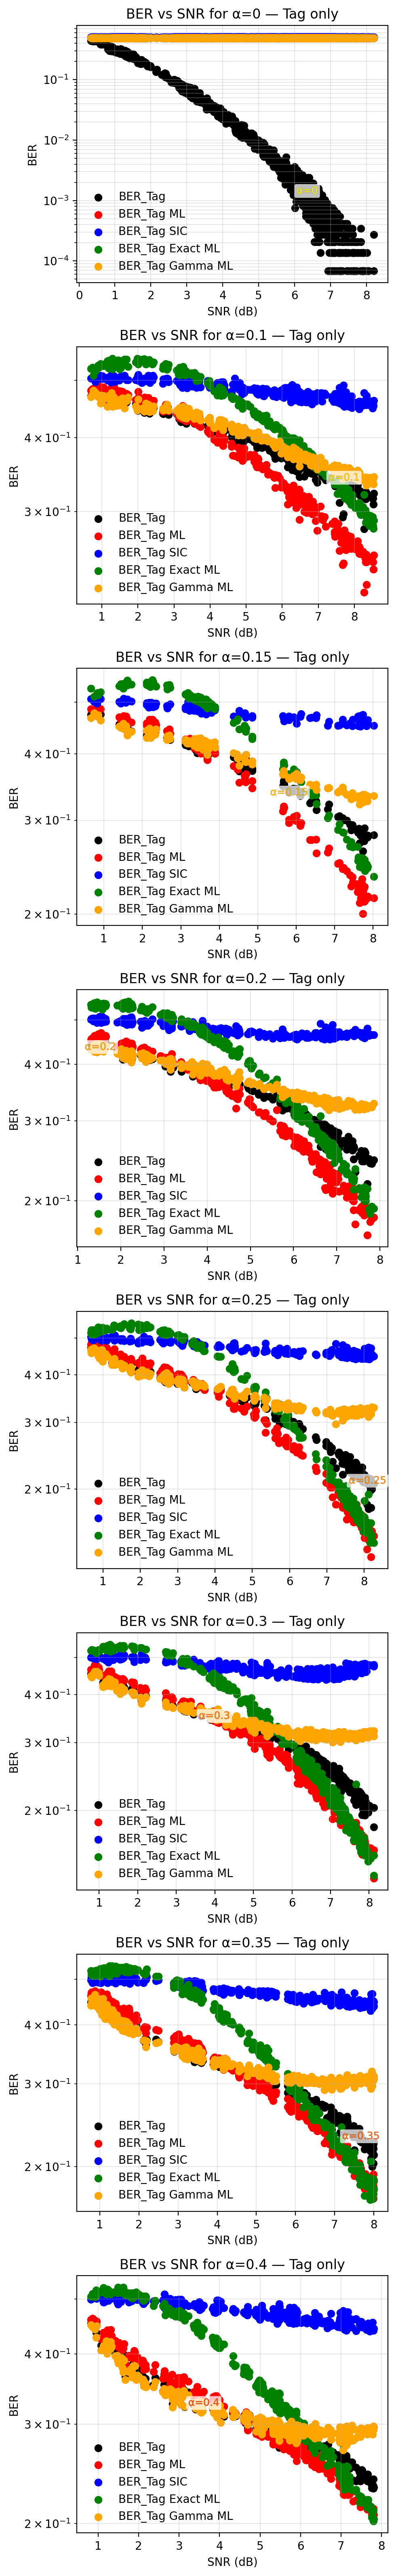

In [10]:
# plot the tag BER for ML and BER_tag
# plot_ber_vs_snr_by_alpha([dbs[0]], save_to="ber_vs_snr_alpha_on_line_ml.png")

# modifying the plot_BER_vs_snr_by_alpha function to show ML and SIC results for tag only and every alpha will be a dufferet subplot
def plot_ber_vs_snr_by_alpha(dfs, save_to=None, compare = True,
                             msg_cmap_name='summer', tag_cmap_name="autumn"):
    series = []
    for alpha, df in dfs.items():
        g = df.copy()
        try:
            if not g.empty:
                series.append((float(alpha), g))
        except:
            pass
    if not series:
        print("No data to plot.")
        return
    # sort so darker (low α) are drawn first, brighter on top
    series.sort(key=lambda x: x[0])
    alphas = [a for a, _ in series]
    a_min, a_max = min(alphas), max(alphas)
    if a_max == a_min:
        a_max = a_min + 1e-12
    norm = mpl.colors.Normalize(vmin=.05*a_min, vmax=1.4*a_max)
    tag_cmap = mpl.cm.get_cmap(tag_cmap_name)   
    fig, axs = plt.subplots(len(series), 1, figsize=(5, 4*len(series)), dpi=200)
    if len(series) == 1:
        axs = [axs]  # ensure axs is always a list
    for ax, (a, g) in zip(axs, series):
        # invert intensity so higher α => brighter
        shade = 1.0 - norm(a)
        tag_color = tag_cmap(shade)

        ax.scatter(g["SNR"], g["BER_tag"], 
                color='black', label="BER_Tag")

        # write α on each line (slightly different positions to reduce overlap)
        _text_on_curve(ax, g["SNR"], g["BER_tag"], f"α={a:g}", tag_color, frac=0.78)
        if compare:
            ax.scatter(g["SNR"], g["BER_tag_ml"], 
                    color='red', label="BER_Tag ML")
            ax.scatter(g["SNR"], g["BER_tag_sic"], 
                     color='blue', label="BER_Tag SIC")
            ax.scatter(g["SNR"], g["BER_tag_exact"], 
                     color='green', label="BER_Tag Exact ML")
            ax.scatter(g["SNR"], g["BER_tag_GammaML"], 
                     color='orange', label="BER_Tag Gamma ML")
            
        # styling
        ax.set_yscale("log")
        ax.set_xlabel("SNR (dB)")
        ax.set_ylabel("BER")
        ax.set_title(f"BER vs SNR for α={a:g} — Tag only")
        ax.grid(True, which="both", alpha=0.3)  
        # tiny legend just for type
        from matplotlib.lines import Line2D
        ax.legend( loc="best", frameon=False)
    fig.tight_layout()
    if save_to:
        fig.savefig(save_to, dpi=220, bbox_inches="tight")
    plt.show()  
# Usage:
plot_ber_vs_snr_by_alpha(dfs, save_to="ber_vs_snr_alpha_on_line_ml_sic.png", compare=True)


BER_msg_ml BER_tag_ml
Index(['SNR', 'BER_tag', 'BER_msg', 'alpha'], dtype='object')
Index(['SNR', 'BER_tag', 'BER_msg', 'alpha'], dtype='object')
Index(['SNR', 'BER_tag', 'BER_msg', 'alpha'], dtype='object')
Index(['SNR', 'BER_tag', 'BER_msg', 'alpha'], dtype='object')
Index(['SNR', 'BER_tag', 'BER_msg', 'alpha'], dtype='object')
Index(['SNR', 'BER_tag', 'BER_msg', 'alpha'], dtype='object')
Index(['SNR', 'BER_tag', 'BER_msg', 'alpha'], dtype='object')
Index(['SNR', 'BER_tag', 'BER_msg', 'alpha'], dtype='object')


/tmp/ipykernel_2637798/2922364802.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  msg_cmap = mpl.cm.get_cmap(msg_cmap_name)
/tmp/ipykernel_2637798/2922364802.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tag_cmap = mpl.cm.get_cmap(tag_cmap_name)


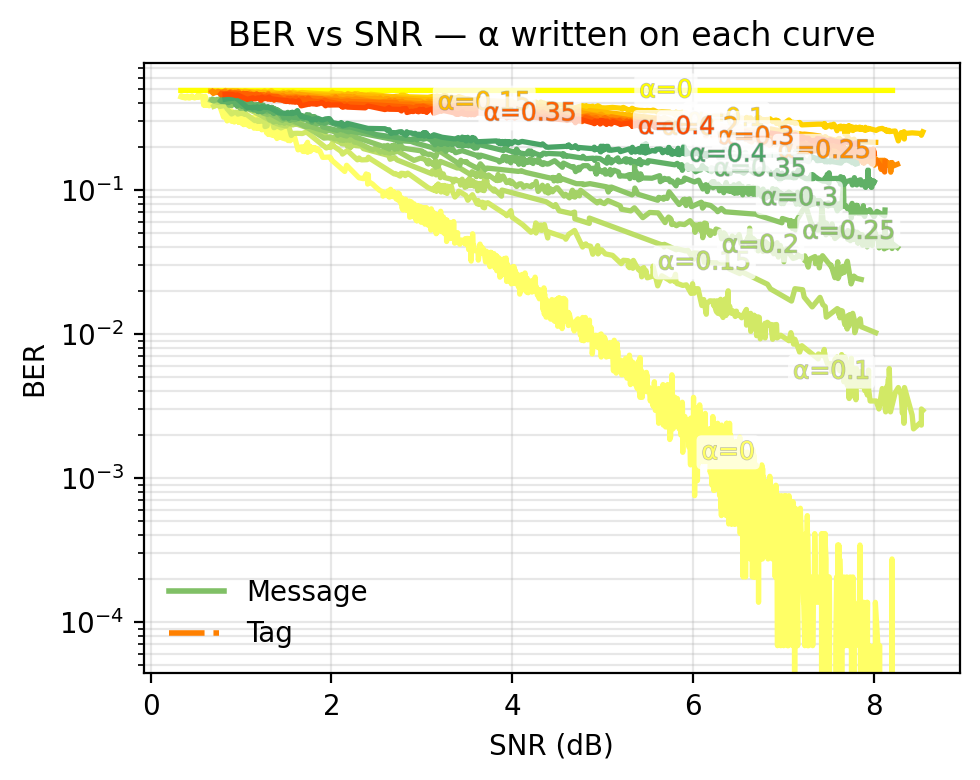

In [11]:
plot_ber_vs_snr_by_alpha_from_dfs(dfs, save_to="ber_vs_snr_alpha_on_line_ml_sic.png",col_name="BER_msg_ml",
                                  col_name2="BER_tag_ml")

In [12]:
from scipy.special import erfc


# Define Q-function
def qfunc(x):
    return 0.5 * erfc(x / np.sqrt(2))
# Error rate function
def error_rate(l, R, p):

    # Avoid log(0) issues by adding a very small number when needed.
    p = np.where(p == 0, 1e-19, p)
    one_minus_p = 1 - p
    C = 1 + p * np.log2(p) + one_minus_p * np.log2(one_minus_p)
    denom = np.log2(one_minus_p / p)
    term = np.sqrt(l / (p * one_minus_p)) * ((C - R) / denom)
    return qfunc(term)

In [13]:
# for a given l and R apply the erorr_rate function to the dfs and add a column name BLER_ml and so on to each BER column in the dfs,

def add_bler_columns(dfs, l, R, col_name="BER_msg_ml", col_name2="BER_tag_ml"):
    for df in dfs.keys():
        dfs[df][f'BLER_{col_name}'] = np.nan
        dfs[df][f'BLER_{col_name2}'] = np.nan
        for i, row in dfs[df].iterrows():
            p_msg = row[col_name]
            p_tag = row[col_name2]
            bler_msg = error_rate(l, ((l-512)//2)/l, p_msg)
            bler_tag = error_rate(l, R, p_tag)
            dfs[df].at[i, f'BLER_{col_name}'] = bler_msg
            dfs[df].at[i, f'BLER_{col_name2}'] = bler_tag
    return dfs
def _infer_MAC_l_r(coll):
    temp = coll.find_one({})["config"]
    r = temp["MAC_REP"]*temp["MAC_LDPC"]
    len_MAC_encoded = int(np.ceil(256/r))
    return len_MAC_encoded, r

mac_encoded,R = _infer_MAC_l_r(dbs[0])
# Example usage

dfs = add_bler_columns(dfs, mac_encoded, R, col_name="BER_msg_ml", col_name2="BER_tag_ml")
dfs = add_bler_columns(dfs, mac_encoded, R, col_name="BER_msg", col_name2="BER_tag")
dfs['0.1'].head() 
# Add BLER columns to df_trad using error_rate for BER_msg and BER_tag
df_trad['BLER_BER_msg'] = error_rate(((mac_encoded-512)), 1/2, df_trad['BER_msg'])
df_trad['BLER_BER_tag'] = error_rate(512, 1/2, df_trad['BER_tag'])
df_trad.head()


,_id,BER_tag,BER_msg,r0,r1,SNR,sigma_n2,config,BER_msg_ml,BER_tag_ml,BER_msg_sic,BER_tag_sic,BER_msg_exact,BER_tag_exact,BLER_BER_msg,BLER_BER_tag
0,689f524433ecf1aab4931356,0.446066,0.446066,"[0.014967702416221723, 0.00010847762194900315,...","[0.019817596846566157, 4.518532282605204e-05, ...",0.576141,1.096457e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.446066,0.490885,0.446066,0.509115,0.446066,0.490885,1.0,1.0
1,689f524833ecf1aab4931358,0.435376,0.435376,"[6.591455987090919e-05, 9.034515179622474e-05,...","[0.00023894709943380368, 0.0001238336551998911...",0.487813,1.096437e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.435376,0.490885,0.435376,0.509115,0.435376,0.490885,1.0,1.0
2,689f525833ecf1aab493135c,0.441954,0.441954,"[0.0003911665962318455, 0.00012416727572418118...","[3.4292736580847825e-05, 0.0001175159371775629...",0.373613,1.114495e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.441954,0.490885,0.441954,0.509115,0.441954,0.490885,1.0,1.0
3,689f525c33ecf1aab493135e,0.438802,0.438802,"[0.016871033027971816, 0.00010438420217698962,...","[0.01337384623593236, 0.00035878864150685525, ...",0.530176,1.114423e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.438802,0.490885,0.438802,0.509115,0.438802,0.490885,1.0,1.0
4,689f526b33ecf1aab4931362,0.440927,0.440927,"[0.00011336254277659907, 8.266106669927841e-05...","[0.00024134050667587852, 1.1431705025852376e-0...",0.449184,1.117788e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.440927,0.490885,0.440927,0.509115,0.440927,0.490885,1.0,1.0


/tmp/ipykernel_2637798/4242512013.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tag_cmap = mpl.cm.get_cmap(tag_cmap_name)


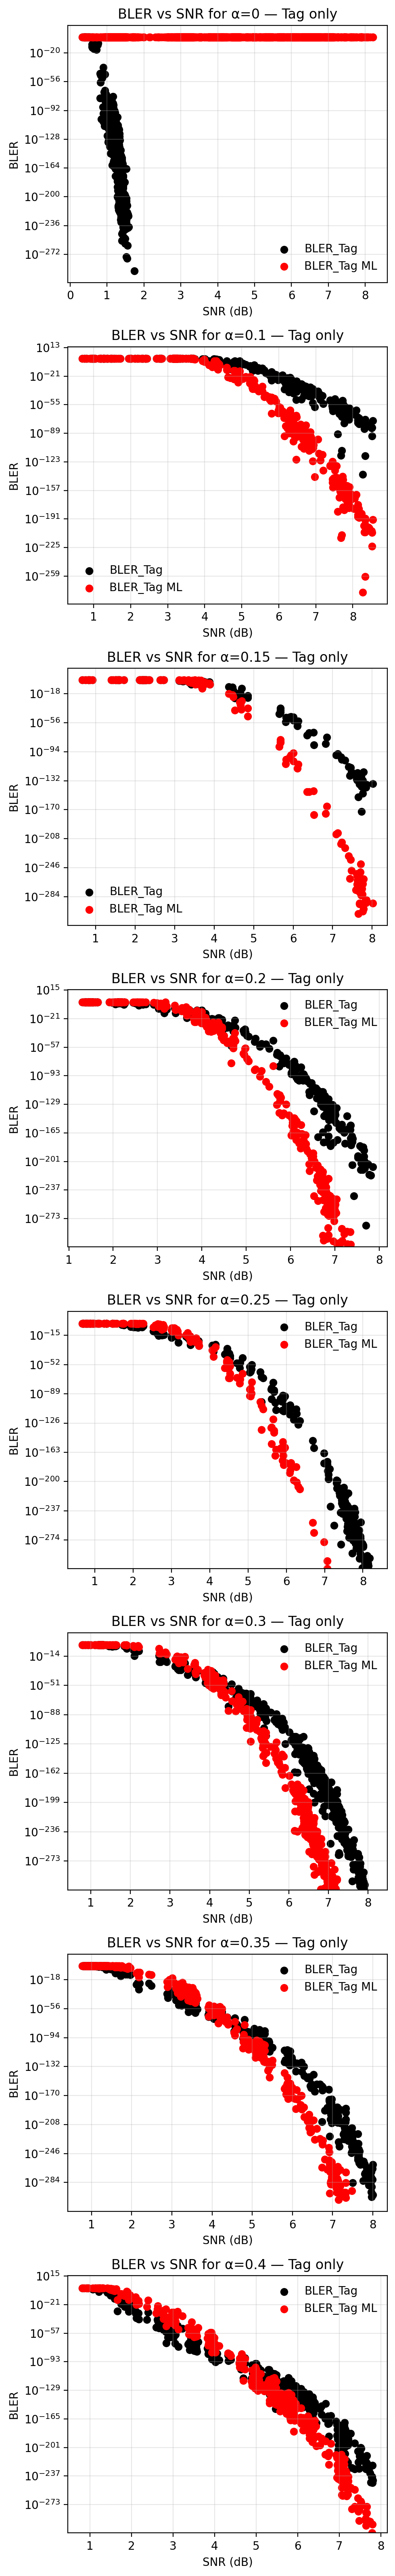

,_id,BER_tag,BER_msg,r0,r1,SNR,sigma_n2,config,BER_msg_ml,BER_tag_ml,...,k_noise,theta_noise,scale_g,leakage_rho,BER_msg_GammaML,BER_tag_GammaML,BLER_BER_msg_ml,BLER_BER_tag_ml,BLER_BER_msg,BLER_BER_tag
0,6894ec1d35183f9455c7fd13,0.449904,0.163994,"[0.014904738910917729, 7.849246126821802e-05, ...","[0.006744261555527553, 0.0012196668619612393, ...",2.433630,1.127641e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.163994,0.461623,...,1.5,0.000159,2109.947485,0.118163,0.163994,0.451686,1.0,1.0,1.0,1.0
1,6894ec2135183f9455c7fd15,0.444490,0.162281,"[0.041491372620181044, 0.00013065247142735173,...","[0.023597497856134637, 0.00016462178017335847,...",2.395581,1.127552e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.162281,0.455592,...,1.5,0.000163,2164.362611,0.122708,0.162281,0.445312,1.0,1.0,1.0,1.0
2,6894ec3135183f9455c7fd19,0.447231,0.161664,"[0.0022260598397238988, 0.00010476026687356567...","[0.0002976798846507594, 6.426555819522752e-05,...",2.333674,1.131830e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.161664,0.459498,...,1.5,0.000156,2067.785482,0.113224,0.161664,0.448739,1.0,1.0,1.0,1.0
3,6894ec3635183f9455c7fd1b,0.444216,0.168654,"[0.050759300140859616, 0.0008476154822279948, ...","[0.03621885812691585, 0.0013718521930755922, 0...",2.408178,1.131802e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.168654,0.456552,...,1.5,0.000170,2250.913241,0.134953,0.168654,0.443394,1.0,1.0,1.0,1.0
4,6894ec4535183f9455c7fd1f,0.444764,0.165502,"[0.0006402595698722706, 0.0001944217765656493,...","[5.3125198396633266e-05, 0.000763268982042842,...",2.402002,1.125144e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.165502,0.453605,...,1.5,0.000154,2051.966249,0.112129,0.165502,0.450726,1.0,1.0,1.0,1.0


In [14]:
# now plot similary the BLER and BLER_msg for tag only and compere every alpha will be a different subplot

def plot_bler_vs_snr_by_alpha(dfs, save_to=None, compare=True,
                                msg_cmap_name='summer', tag_cmap_name="autumn"):
        series = []
        for alpha, df in dfs.items():
            g = df.copy()
            try:
                if not g.empty:
                    series.append((float(alpha), g))
            except:
                pass
        if not series:
            print("No data to plot.")
            return
        # sort so darker (low α) are drawn first, brighter on top
        series.sort(key=lambda x: x[0])
        alphas = [a for a, _ in series]
        a_min, a_max = min(alphas), max(alphas)
        if a_max == a_min:
            a_max = a_min + 1e-12
        norm = mpl.colors.Normalize(vmin=.05*a_min, vmax=1.4*a_max)
        tag_cmap = mpl.cm.get_cmap(tag_cmap_name)   
        fig, axs = plt.subplots(len(series), 1, figsize=(5, 4*len(series)), dpi=200)
        if len(series) == 1:
            axs = [axs]  # ensure axs is always a list
        for ax, (a, g) in zip(axs, series):
            # invert intensity so higher α => brighter
            shade = 1.0 - norm(a)
            tag_color = tag_cmap(shade)
    
            ax.scatter(g["SNR"], g["BLER_BER_tag"], 
                    color='black', label="BLER_Tag")
    
            # write α on each line (slightly different positions to reduce overlap)
            # _text_on_curve(ax, g["SNR"], g["BLER_BER_tag"], f"α={a:g}", tag_color, frac=0.78)
            if compare:
                ax.scatter(g["SNR"], g["BLER_BER_tag_ml"], 
                        color='red', label="BLER_Tag ML")
                # ax.scatter(g["SNR"], g["BLER_tag_sic"], 
                #         color='blue', label="BLER_Tag SIC")
                # ax.scatter(g["SNR"], g["BLER_tag_exact"], 
                #         color='green', label="BLER_Tag Exact ML")
                # ax.scatter(g["SNR"], g["BLER_tag_GammaML"], 
                #         color='orange', label="BLER_Tag Gamma ML")
            # styling
            ax.set_yscale("log")
            ax.set_xlabel("SNR (dB)")
            ax.set_ylabel("BLER")
            ax.set_title(f"BLER vs SNR for α={a:g} — Tag only")
            ax.grid(True, which="both", alpha=0.3)  
           # y linm to [1e-5, 1]
            # ax.set_ylim([1e-5, 1])

            

            # tiny legend just for type
            from matplotlib.lines import Line2D
            ax.legend( loc="best", frameon=False)
        fig.tight_layout()
        if save_to:
            fig.savefig(save_to, dpi=220, bbox_inches="tight")
        

        plt.show()
# Usage:
plot_bler_vs_snr_by_alpha(dfs, save_to="bler_vs_snr_alpha_on_line_ml_sic.png", compare=True)
dfs['0.1'].head()

/tmp/ipykernel_2637798/2010445695.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tag_cmap = mpl.cm.get_cmap(tag_cmap_name)


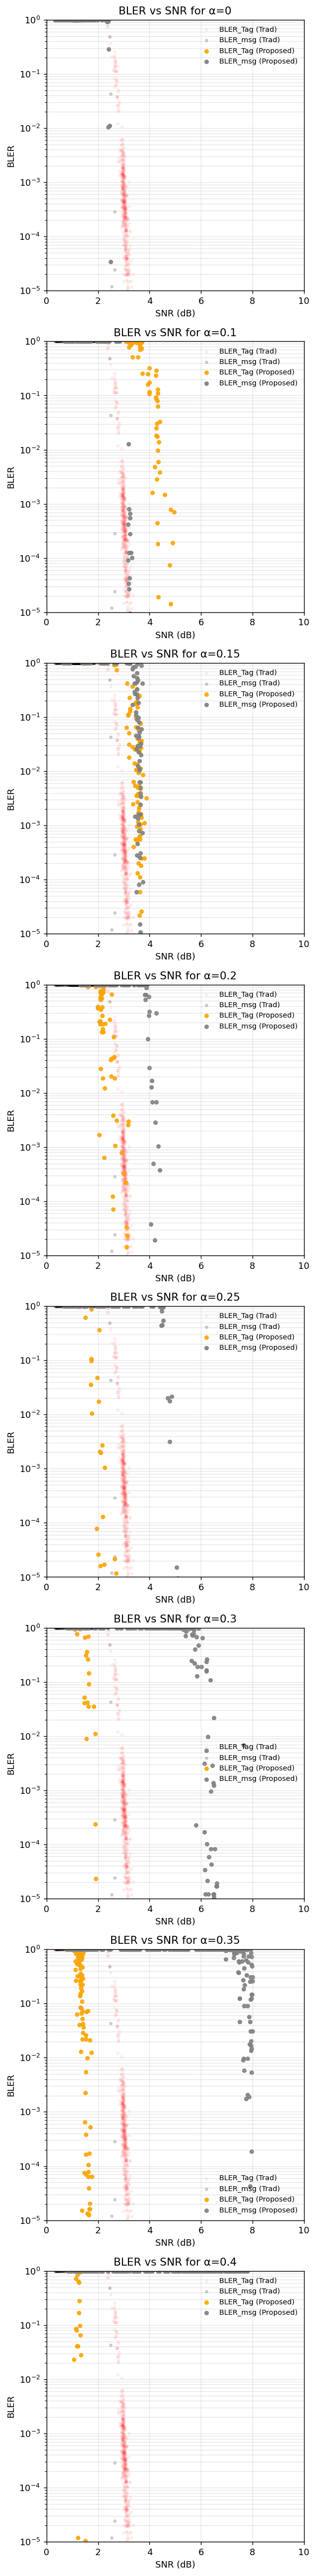

In [15]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

def _safe_log10(y, eps=1e-12):
    y = np.asarray(y, dtype=float)
    return np.log10(np.clip(y, eps, None))

def _polyfit_logy(x, y, degree=1):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y) & (y > 0)
    if m.sum() <= degree:
        return None, None, None
    lx, ly = x[m], _safe_log10(y[m])
    coeffs = np.polyfit(lx, ly, degree)
    p = np.poly1d(coeffs)
    # R^2 in log domain
    yhat = p(lx)
    ss_res = np.sum((ly - yhat)**2)
    ss_tot = np.sum((ly - ly.mean())**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    return p, coeffs, r2

def _fit_and_plot(ax, x, y, degree, color, label, linestyle='--', lw=2, annotate=False, y_off=0.94):
    p, c, r2 = _polyfit_logy(x, y, degree)
    if p is None:
        return
    xfit = np.linspace(np.nanmin(x), np.nanmax(x), 200)
    yfit = 10**p(xfit)   # back from log10-space
    ax.plot(xfit, yfit, linestyle=linestyle, linewidth=lw, color=color, label=f"{label} fit (deg {degree})")
    if annotate:
        # log10(y) = c0*SNR^n + ...; short text
        coeffs_str = " + ".join([f"{v:.3g}·SNR^{i}" for i, v in zip(range(len(c)-1, -1, -1), c)])
        ax.text(0.02, y_off, f"log10(y) = {coeffs_str}\nR²={r2:.3f}",
                transform=ax.transAxes, ha='left', va='top', fontsize=7,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.6))

def plot_bler_vs_snr_trad_and_dfs(
    dfs, df_trad, save_to=None, compare=True,
    msg_cmap_name='summer', tag_cmap_name='autumn',
    fit_degree=1, show_combined=False, trad_sample=None,
    ylim=(1e-5, 1), xlim=None, annotate_fits=False
):
    # collect valid series
    series = []
    for alpha, df in dfs.items():
        try:
            if df is not None and not df.empty:
                series.append((float(alpha), df))
        except Exception:
            pass
    if not series:
        print("No data to plot.")
        return

    # sort by alpha
    series.sort(key=lambda x: x[0])
    alphas = [a for a, _ in series]
    a_min, a_max = min(alphas), max(alphas)
    if a_max == a_min: a_max = a_min + 1e-12

    norm = mpl.colors.Normalize(vmin=.05*a_min, vmax=1.4*a_max)
    tag_cmap = mpl.cm.get_cmap(tag_cmap_name)

    n_rows = len(series) + (1 if show_combined else 0)
    fig, axs = plt.subplots(n_rows, 1, figsize=(5, 5*len(series)), dpi=130)
    if n_rows == 1:
        axs = [axs]
    per_alpha_axes = axs[:len(series)]
    combined_ax = axs[-1] if show_combined else None

    # optionally thin traditional scatter
    trad_idx = np.arange(len(df_trad))
    if trad_sample is not None and len(trad_idx) > trad_sample:
        trad_idx = np.random.choice(trad_idx, size=trad_sample, replace=False)
    df_trad_plot = df_trad.iloc[trad_idx] if trad_sample else df_trad

    for ax, (a, g) in zip(per_alpha_axes, series):
        shade = 1.0 - norm(a)
        tag_color = tag_cmap(shade)

        # ---- TRAD: scatter ----
        ax.scatter(df_trad_plot["SNR"], df_trad_plot["BLER_BER_tag"],
                   s=8, color='red',   alpha=0.05, label="BLER_Tag (Trad)")
        ax.scatter(df_trad_plot["SNR"], df_trad_plot["BLER_BER_msg"],
                   s=8, color='black', alpha=0.15, label="BLER_msg (Trad)")

        # ---- TRAD: fits (Tag + Msg) ----
        # _fit_and_plot(ax, df_trad["SNR"], df_trad["BLER_BER_tag"], fit_degree,
        #               color='red', label="Trad Tag", annotate=annotate_fits, y_off=0.94)
        # _fit_and_plot(ax, df_trad["SNR"], df_trad["BLER_BER_msg"], fit_degree,
        #               color='black', label="Trad Msg", annotate=False)

        if compare:
            # ---- PROPOSED: scatter ----
            ax.scatter(g["SNR"], g["BLER_BER_tag"],
                       s=16, color='orange', alpha=0.9, label="BLER_Tag (Proposed)")
            ax.scatter(g["SNR"], g["BLER_BER_msg"],
                       s=16, color='gray',   alpha=0.9, label="BLER_msg (Proposed)")

# TRAD fits
            # _robust_fit_and_plot(ax, df_trad["SNR"], df_trad["BLER_BER_tag"],
            #                     degree=1, color='red',   label="Trad Tag",
            #                     method="bin-median", bin_width=0.2, min_per_bin=5, annotate=True)

            # _robust_fit_and_plot(ax, df_trad["SNR"], df_trad["BLER_BER_msg"],
            #                     degree=1, color='black', label="Trad Msg",
            #                     method="bin-median", bin_width=0.2, min_per_bin=5)

            # # PROPOSED fits
            # _robust_fit_and_plot(ax, g["SNR"], g["BLER_BER_tag"],
            #                     degree=1, color='orange', label="Prop Tag",
            #                     method="bin-median", bin_width=0.2, min_per_bin=3, annotate=True, y_off=0.78)

            # _robust_fit_and_plot(ax, g["SNR"], g["BLER_BER_msg"],
            #                     degree=1, color='gray',   label="Prop Msg",
            #                     method="bin-median", bin_width=0.2, min_per_bin=3)


        # formatting
        ax.set_yscale("log")
        ax.set_ylim(ylim)
        if xlim: ax.set_xlim(xlim)
        ax.set_xlabel("SNR (dB)")
        ax.set_ylabel("BLER")
        ax.set_title(f"BLER vs SNR for α={a:g}")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend(loc="best", frameon=False, fontsize=8)

        # optional combined panel (proposed tag + fits by color)
        if combined_ax is not None and compare:
            combined_ax.scatter(g["SNR"], g["BLER_BER_tag"], s=10, color=tag_color, alpha=0.6, label=f"α={a:g}")
            # add proposed-tag fit there too
            p, _, _ = _polyfit_logy(g["SNR"], g["BLER_BER_tag"], degree=fit_degree)
            if p is not None:
                xfit = np.linspace(np.nanmin(g["SNR"]), np.nanmax(g["SNR"]), 150)
                combined_ax.plot(xfit, 10**p(xfit), color=tag_color, linewidth=1.4, alpha=0.9)

    if combined_ax is not None:
        combined_ax.set_yscale("log")
        combined_ax.set_ylim(ylim)
        if xlim: combined_ax.set_xlim(xlim)
        combined_ax.set_xlabel("SNR (dB)")
        combined_ax.set_ylabel("BLER")
        combined_ax.set_title("Combined (all α) — Proposed tag + fits")
        combined_ax.grid(True, which="both", alpha=0.3)
        handles, labels = combined_ax.get_legend_handles_labels()
        uniq = dict(zip(labels, handles))
        combined_ax.legend(uniq.values(), uniq.keys(), frameon=False, fontsize=8, ncol=2)

    fig.tight_layout()
    if save_to:
        fig.savefig(save_to, dpi=220, bbox_inches="tight")
    plt.show()

plot_bler_vs_snr_trad_and_dfs(
    dfs, df_trad,
    save_to="bler_vs_snr_all_fits.png",
    compare=True,
    fit_degree=5,        # 1 = straight line in log-space; try 2 for a gentle curve
    trad_sample=4000,    # thin dense “Trad” points for readability
    xlim=(0, 10),
    ylim=(1e-5, 1),
    annotate_fits=False  # True to print equations & R² on panels
)


In [16]:
import numpy as np
from sklearn.linear_model import RANSACRegressor, LinearRegression, HuberRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

def _safe_log10(y, eps=1e-12):
    y = np.asarray(y, dtype=float)
    return np.log10(np.clip(y, eps, None))

def _bin_reduce_median(x, y, bin_width=0.2, min_per_bin=3):
    """Group by SNR bins and take median BLER per bin."""
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (y > 0)
    x, y = x[m], y[m]
    if x.size == 0:
        return None, None
    # bin edges
    xmin, xmax = np.min(x), np.max(x)
    edges = np.arange(xmin, xmax + bin_width, bin_width)
    if edges.size < 2:
        return None, None
    # digitize and aggregate
    b = np.digitize(x, edges) - 1
    xb, yb = [], []
    for bi in range(edges.size - 1):
        sel = (b == bi)
        if np.sum(sel) >= min_per_bin:
            xb.append(np.median(x[sel]))
            yb.append(np.median(y[sel]))
    if not xb:
        return None, None
    return np.array(xb), np.array(yb)

def _polyfit_logy_binned(x, y, degree=1, bin_width=0.2, min_per_bin=3):
    """Bin by SNR, take medians, then polyfit log10(BLER)."""
    xb, yb = _bin_reduce_median(x, y, bin_width=bin_width, min_per_bin=min_per_bin)
    if xb is None:
        return None, None, None
    coeffs = np.polyfit(xb, _safe_log10(yb), degree)
    p = np.poly1d(coeffs)
    # R^2 on binned data
    yhat = p(xb)
    ss_res = np.sum((_safe_log10(yb) - yhat)**2)
    ss_tot = np.sum((_safe_log10(yb) - _safe_log10(yb).mean())**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    return p, coeffs, r2

def _ransac_poly_logy(x, y, degree=1, residual_threshold=0.15, min_samples=0.5):
    """
    Robust poly in x to log10(y) using RANSAC.
    residual_threshold ~ error tolerance in log10(BLER) units.
    """
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (y > 0)
    x, y = x[m], y[m]
    if x.size <= degree + 2:
        return None, None, None

    # Pipeline: PolynomialFeatures -> LinearRegression wrapped by RANSAC
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=True)),
        ("lr", LinearRegression())
    ])
    ransac = RANSACRegressor(
        base_estimator=model,
        residual_threshold=residual_threshold,
        min_samples=min_samples,
        random_state=0
    )
    X = x.reshape(-1, 1)
    ransac.fit(X, _safe_log10(y))

    # Build a callable poly1d for convenience
    # Extract coefficients from inner LinearRegression after poly transform
    lr = ransac.estimator_.named_steps["lr"]
    poly = ransac.estimator_.named_steps["poly"]
    # Reconstruct polynomial coefficients in x-domain
    # lr.coef_ maps to feature powers; convert to poly1d
    # NOTE: For degree>1, we need the full mapping; poly.get_feature_names_out gives terms.
    # For simplicity we evaluate via the pipeline instead of a closed-form poly1d:
    def p_eval(xx):
        XX = poly.transform(np.asarray(xx).reshape(-1,1))
        return lr.predict(XX)
    p = lambda xx: p_eval(xx)  # returns log10(y_hat)

    # R^2 on inliers (log-domain)
    inliers = ransac.inlier_mask_
    y_true = _safe_log10(y[inliers])
    y_pred = ransac.predict(X[inliers])
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

    # We can’t easily expose compact poly1d coefficients for degree>1 via pipeline; return None for coeffs
    return p, None, r2

def robust_fit_logy(x, y, degree=3, method="bin-median",
                    bin_width=0.2, min_per_bin=3,
                    residual_threshold=0.15, min_samples=0.5):
    """
    Returns (predictor, coeffs, r2) where predictor(X) yields log10(y_hat).
    method: 'bin-median' or 'ransac' or 'huber'
    """
    if method == "bin-median":
        p, coeffs, r2 = _polyfit_logy_binned(x, y, degree=degree,
                                             bin_width=bin_width, min_per_bin=min_per_bin)
        if p is None: 
            return None, None, None
        return (lambda xx: p(np.asarray(xx))), p.c, r2

    if method == "ransac":
        return _ransac_poly_logy(x, y, degree=degree,
                                 residual_threshold=residual_threshold,
                                 min_samples=min_samples)

    if method == "huber" and degree == 1:
        # Linear (degree=1) robust regression with Huber
        x = np.asarray(x, float)
        y = np.asarray(y, float)
        m = np.isfinite(x) & np.isfinite(y) & (y > 0)
        x, y = x[m], y[m]
        if x.size < 3:
            return None, None, None
        X = x.reshape(-1, 1)
        hub = HuberRegressor().fit(X, _safe_log10(y))
        p = lambda xx: hub.predict(np.asarray(xx).reshape(-1,1))
        yhat = hub.predict(X)
        ss_res = np.sum((_safe_log10(y) - yhat)**2)
        ss_tot = np.sum((_safe_log10(y) - _safe_log10(y).mean())**2)
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
        return p, np.array([hub.intercept_, hub.coef_[0]]), r2

    return None, None, None

# Example usage of robust_fit_logy
def _robust_fit_and_plot(ax, x, y, degree, color, label,
                         method="bin-median", linestyle='--', lw=2,
                         annotate=False, y_off=0.94,
                         **kwargs):
    p, coeffs, r2 = robust_fit_logy(x, y, degree=degree, method=method, **kwargs)
    if p is None:
        return
    x = np.asarray(x, float)
    xfit = np.linspace(np.nanmin(x), np.nanmax(x), 200)
    yfit = 10**p(xfit)  # back to linear BLER
    ax.plot(xfit, yfit, linestyle=linestyle, linewidth=lw, color=color,
            label=f"{label} fit ({method})")
    if annotate:
        txt = f"R²={r2:.3f} ({method})"
        ax.text(0.02, y_off, txt, transform=ax.transAxes,
                ha='left', va='top', fontsize=7,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.6))



/tmp/ipykernel_2637798/4071096246.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  term = np.sqrt(l / (p * one_minus_p)) * ((C - R) / denom)


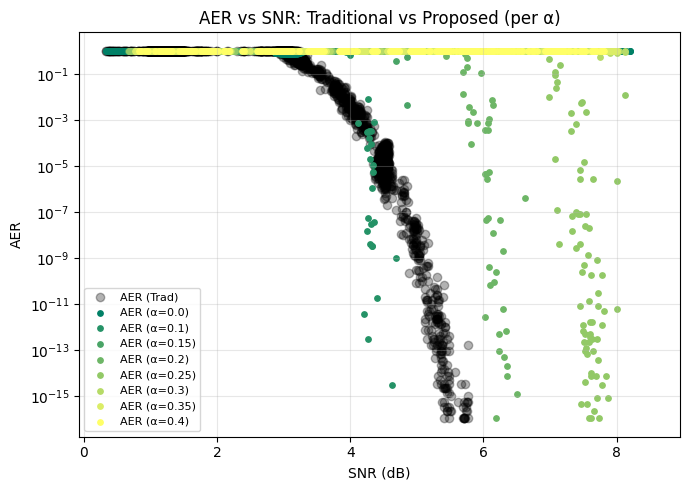

In [17]:
def add_bler_columns(dfs, total_length, R_proposed_msg, R_proposed_tag, col_name="BER_msg_ml", col_name2="BER_tag_ml"):
    for df in dfs.keys():
        dfs[df][f'BLER_{col_name}'] = np.nan
        dfs[df][f'BLER_{col_name2}'] = np.nan
        for i, row in dfs[df].iterrows():
            p_msg = row[col_name]
            p_tag = row[col_name2]
            snr = row['SNR']
            snr = 10**(snr/10)  # convert dB to linear
            ber_tag_SIC = qfunc(np.sqrt(float(df)*snr))
            # print(f"SNR: {snr}, alpha: {df}, ber_tag_SIC: {ber_tag_SIC}, p_msg: {p_msg}, p_tag: {p_tag}")
            bler_msg = error_rate(total_length, R_proposed_msg, p_msg)
            bler_tag = error_rate(total_length, R_proposed_tag, p_tag)

            bler_tag_SIC = error_rate(total_length, R_proposed_tag, ber_tag_SIC)

            # print(f"BLER_msg: {bler_msg}, BLER_tag: {bler_tag}, BLER_tag_SIC: {bler_tag_SIC}")
            

            dfs[df].at[i, f'BLER_{col_name}'] = bler_msg
            dfs[df].at[i, f'BLER_{col_name2}'] = bler_tag_SIC*(1-bler_msg) + bler_tag*bler_msg
    return dfs
def _infer_MAC_l_r(coll):
    temp = coll.find_one({})["config"]
    r = temp["MAC_REP"]*temp["MAC_LDPC"]
    len_MAC_encoded = int(np.ceil(256/r))
    return len_MAC_encoded, r

# mac_encoded,R = _infer_MAC_l_r(dbs[0])
# Example usage

total_length = 15000
R_trad = 2/3
mac_before_encoding = 128

Mac_size = int(np.ceil(mac_before_encoding/R_trad))

Msg_size = total_length - Mac_size  # 256 bits for tag
R_proposed_tag = mac_before_encoding/total_length
R_proposed_msg = Msg_size*R_trad/total_length

# print(f"Total length: {total_length},R_trad: {R_trad}, R_proposed_msg: {R_proposed_msg}, R_proposed_tag: {R_proposed_tag}")


dfs = add_bler_columns(dfs, total_length,R_proposed_msg,R_proposed_tag , col_name="BER_msg_ml", col_name2="BER_tag_ml")
dfs = add_bler_columns(dfs, total_length,R_proposed_msg,R_proposed_tag , col_name="BER_msg", col_name2="BER_tag")
dfs['0.1'].head() 
# Add BLER columns to df_trad using error_rate for BER_msg and BER_tag
df_trad['BLER_BER_msg'] = error_rate(Msg_size, R_trad, df_trad['BER_msg'])
df_trad['BLER_BER_tag'] = error_rate(Mac_size, R_trad, df_trad['BER_tag'])




for k, df in dfs.items():
    if 'BLER_BER_msg' in df.columns and 'BLER_BER_tag' in df.columns:
        dfs[k]['AER'] = 1 - (1 - df['BLER_BER_msg']) * (1 - df['BLER_BER_tag'])

if 'BLER_BER_msg' in df_trad.columns and 'BLER_BER_tag' in df_trad.columns:
    df_trad['AER'] = 1 - (1 - df_trad['BLER_BER_msg']) * (1 - df_trad['BLER_BER_tag'])

# Plot AER for traditional and proposed (for each alpha)
plt.figure(figsize=(7, 5))
plt.scatter(df_trad['SNR'], df_trad['AER'], color='black', alpha=.3, label='AER (Trad)')

colors = plt.cm.summer(np.linspace(0, 1, len(dfs)))
for idx, (alpha, df) in enumerate(sorted(dfs.items(), key=lambda x: float(x[0]))):
    plt.scatter(df['SNR'], df['AER'], s=15, color=colors[idx], alpha=1, label=f'AER (α={alpha})')

plt.yscale('log')
plt.xlabel('SNR (dB)')
plt.ylabel('AER')
plt.title('AER vs SNR: Traditional vs Proposed (per α)')
plt.grid(True, which='both', alpha=0.3)
plt.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()